# Preprocess subsetted scATAC-seq data from Furlong using SparSCit
Add metadata, filter, save

In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import sys
sys.path.insert(0, './toolkit-project')
import src as toolkit

In [7]:
atac = ad.read_h5ad("../h5ad/atac_120k_subset.h5ad")

In [9]:
toolkit.tl.X_to_layer(atac, 'atac')

In [11]:
toolkit.tl.add_metadata(atac, var_loc_metadata=False)

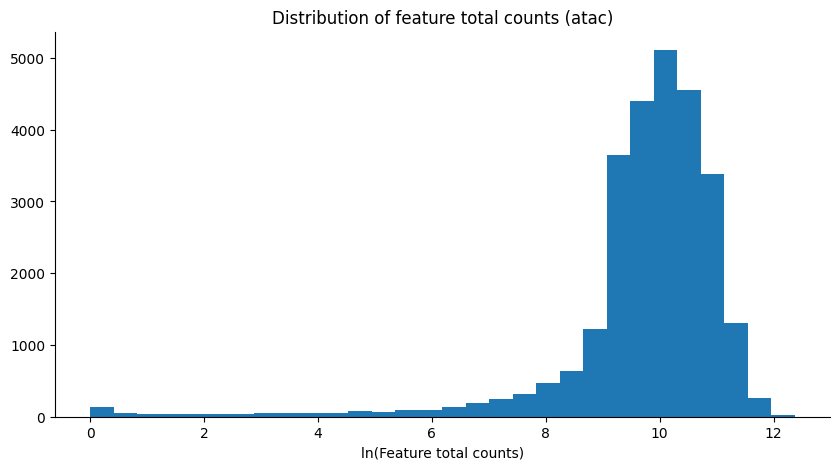

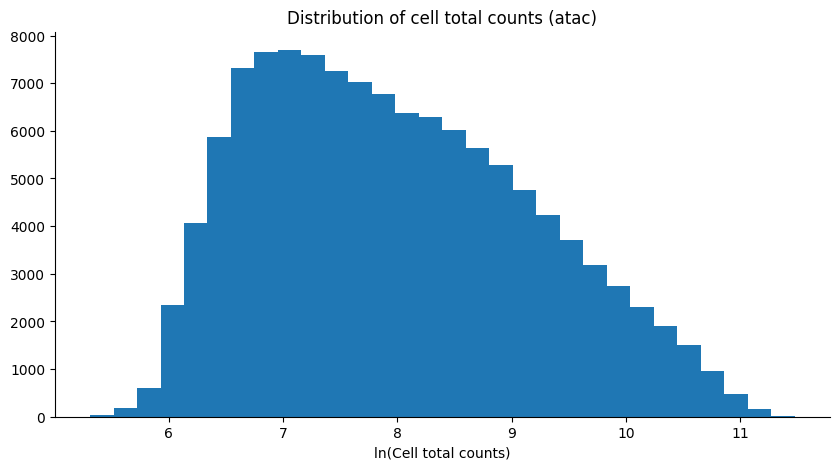

In [12]:
toolkit.pl.features_counts_histogram(atac)
toolkit.pl.cells_counts_histogram(atac)

In [13]:
atac=toolkit.tl.filter(atac, ['atac'], min_feature_counts=[20], return_purged=True)

In [14]:
toolkit.em.spectral(atac, 'atac')

/faststorage/project/PAN_illumina/people/artem/singlecell/jnb/toolkit-project/src/embedding/_spectral.py:105: ImplicitModificationWarning: Setting element `.obsm['X_spectral']` of view, initializing view as actual.
  adata.obsm['X_spectral'] = np.flip(eigenvectors, axis=1)


array([1.        , 0.05345902, 0.03416663, 0.023731  , 0.0180198 ,
       0.01659006, 0.01235528, 0.01058121, 0.00898954, 0.00680545,
       0.00534629, 0.00494728, 0.00436578, 0.0039366 , 0.00353791,
       0.00332287, 0.0032901 , 0.00320524, 0.00292147, 0.0028345 ,
       0.00264192, 0.00259022, 0.00251157, 0.00237948, 0.00231097])

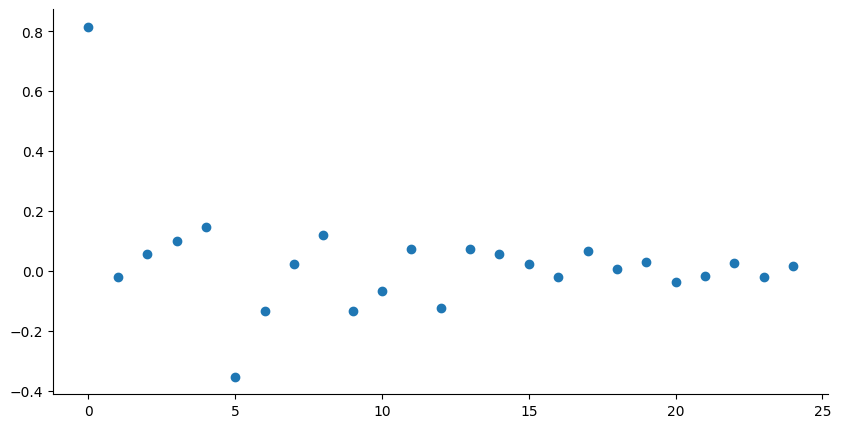

In [15]:
toolkit.pl.depth_corr(atac, 'X_spectral', 'atac')

In [16]:
toolkit.tl.remove_pc(atac, 'X_spectral', 0)

/home/artem/miniconda3/envs/singlecell2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


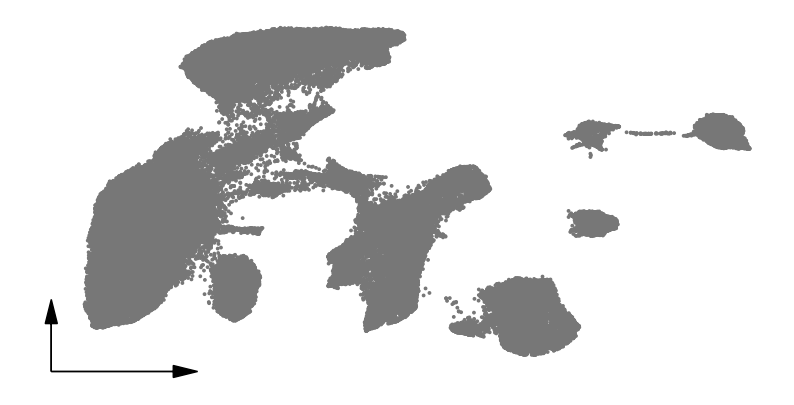

In [17]:
toolkit.em.umap(atac, 'X_spectral')
toolkit.pl.embedding2d(atac, 'X_umap')

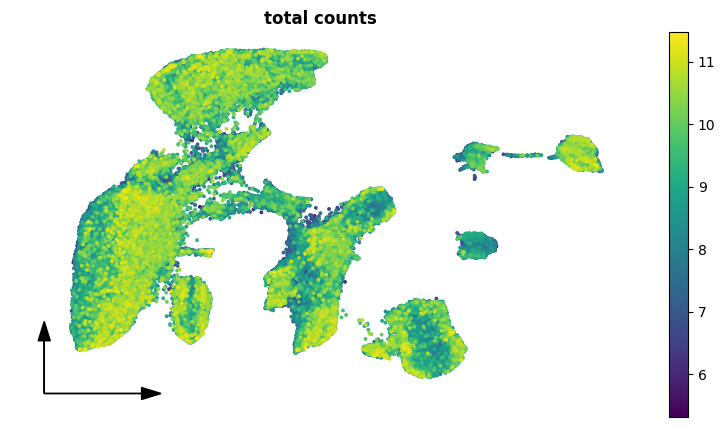

In [18]:
toolkit.pl.embedding2d(atac, 'X_umap', 'atac_log_total_counts', title='total counts')

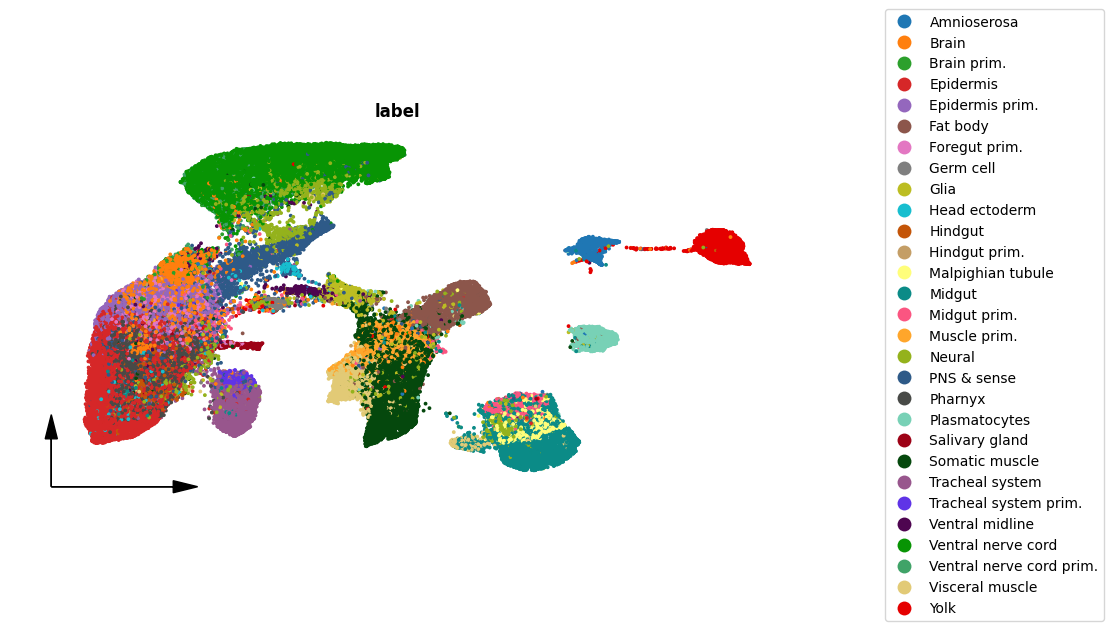

In [21]:
toolkit.pl.embedding2d(atac, 'X_umap', 'label', title='label')

In [22]:
atac.write_h5ad("../h5ad/pp_atac120k.h5ad")